In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
car_mpg = pd.read_csv('cars-dataset.csv')

In [3]:
#fetch few records to understand the data
car_mpg.head(5)

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [4]:
#shape of the data to check the dimensions(no of columns and rows)
car_mpg.shape

(398, 8)

In [5]:
#Check the data types
car_mpg.dtypes

car name     object
cyl           int64
disp        float64
hp           object
wt            int64
acc         float64
yr            int64
mpg         float64
dtype: object

In [6]:
#I see we have 2 features(Car name,hp) which are objects(non numeric)

In [7]:
car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [8]:
#There are no missing values, we have all the 398 records from all the features.

In [9]:
car_mpg.describe().T

,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [10]:
#Observations from the describe function:
#The mean and median values of wt,acc,yr,mpg are almost the same. Which shows the norrmal distrubution of the data.

### 1. Launch a new python notebook and read the data set. 
### EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points

In [11]:
# Below code gives the information if feature(hp) which is non numeric about numeric values.
#Other features does not return anything, only hp feature has the below:
print (car_mpg[pd.to_numeric(car_mpg['hp'],errors='coerce').isnull()])

                 car name  cyl   disp hp    wt   acc  yr   mpg
32             ford pinto    4   98.0  ?  2046  19.0  71  25.0
126         ford maverick    6  200.0  ?  2875  17.0  74  21.0
330  renault lecar deluxe    4   85.0  ?  1835  17.3  80  40.9
336    ford mustang cobra    4  140.0  ?  2905  14.3  80  23.6
354           renault 18i    4  100.0  ?  2320  15.8  81  34.5
374        amc concord dl    4  151.0  ?  3035  20.5  82  23.0


In [12]:
#We could see that on index 32,126,330,336,354 and 374 we have the values for hp as '?'

In [13]:
temp = pd.DataFrame(car_mpg.hp.str.isdigit()) 
temp[temp['hp'] == False]

,hp
32,False
126,False
330,False
336,False
354,False
374,False


In [14]:
#remvoing the non numeric values from hp.
car_mpg = car_mpg.replace('?', np.nan)

In [15]:
car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          392 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [16]:
#We could see that the 6 rows have been removed, the count of rows for hp is now 392

In [17]:
#convert the hp feature to float
car_mpg['hp'] = car_mpg['hp'].astype('float64')

In [18]:
car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          392 non-null float64
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [19]:
numeric_cols = car_mpg.drop('car name', axis=1)

# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
car_names = pd.DataFrame(car_mpg[['car name']])


numeric_cols = numeric_cols.apply(lambda x: x.fillna(x.median()),axis=0)
car_mpg = numeric_cols.join(car_names)   # Recreating mpg_df by combining numerical columns with car names

car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null float64
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
car name    398 non-null object
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


### 2.Use pair plot or scatter matrix to visualize how the different variables are related 
###    (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters                    existing in the dataset) – 5 points

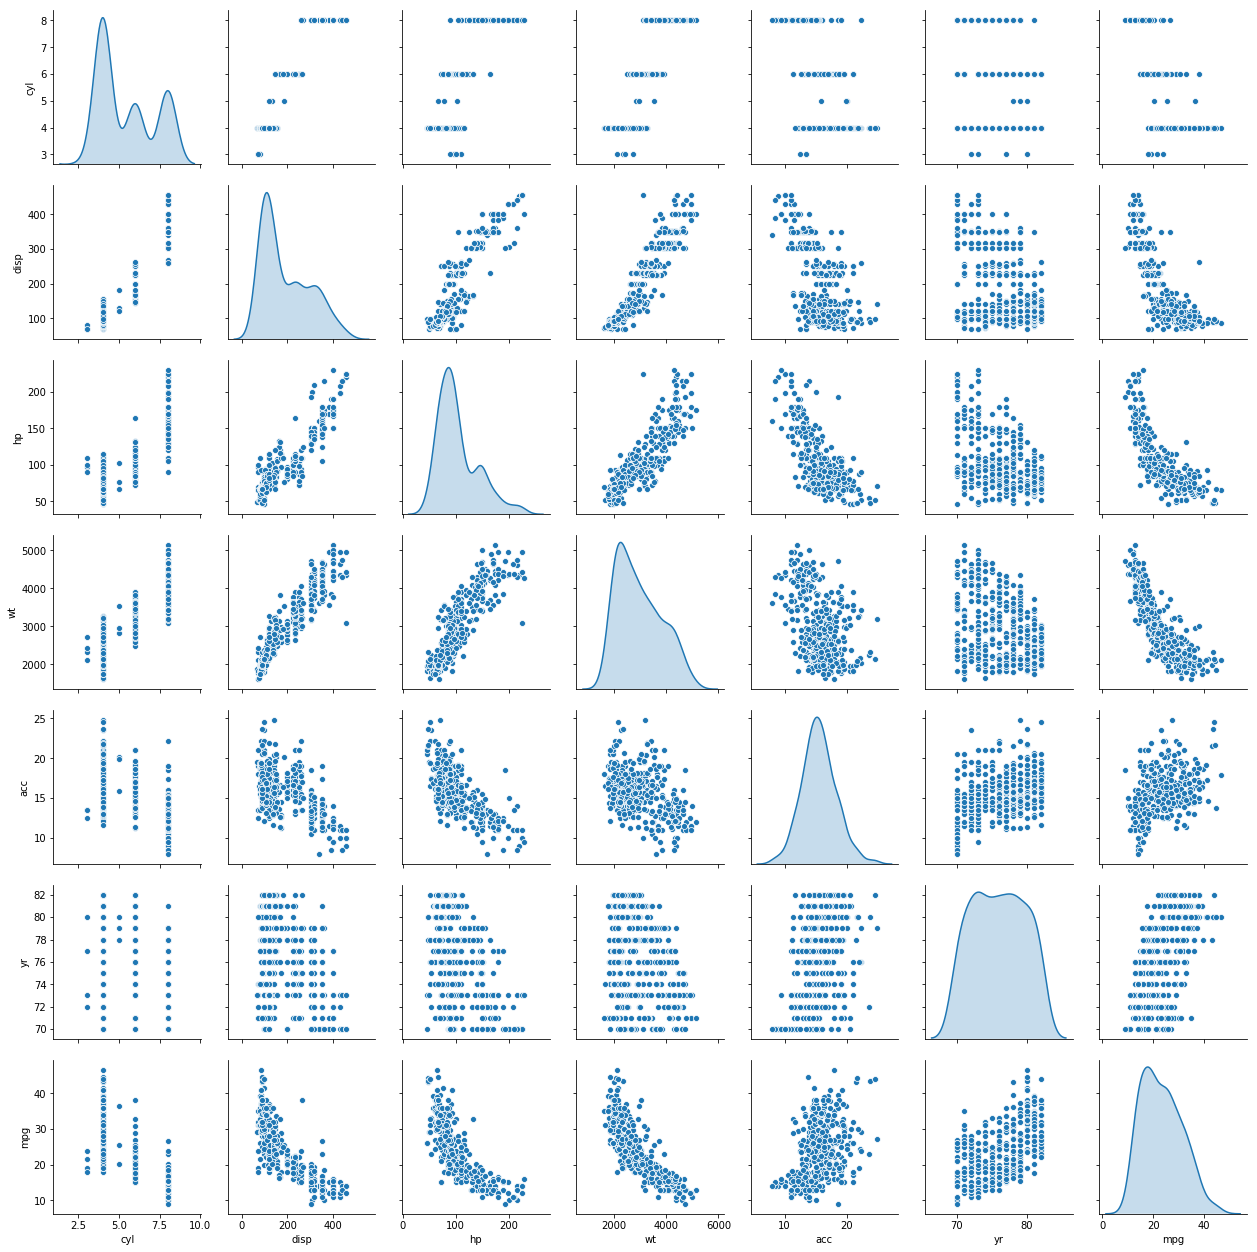

In [20]:
sns.pairplot(car_mpg,diag_kind='kde')

In [21]:
#Observations:
#We can see the there are 3 peaks for the mpg feature, so minimum no of clusters will be 3
#There is a strong positive corelation of wt with cyl,disp and hp
#Acc plot is normally distrubuted, with a perfect peak.
#While there is negative coorelation between acc and hp
#We could see the mpg has a negative curvilinear relation with cyl,disp,hp and wt.While acc is spread across.

In [22]:
#Lets verify the correlation as mentioned in the scatter plot obsevation with heatmap.

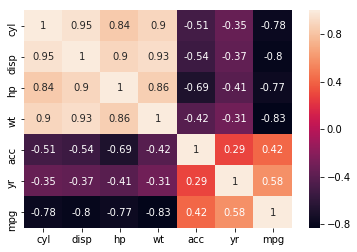

In [23]:
correlation = car_mpg.corr()
sns.heatmap(correlation,annot=True)

### 3.Use K Means or Hierarchical clustering to find out the optimal number of  clusters in the data.
###    Identify and separate the clusters (10 points)

In [24]:
# we have to apply z score before proceeding further
#Car name is non numerical, hence droping the same to apply Zscore
from scipy.stats import zscore
X = car_mpg.drop('car name',axis=1)
car_mpg_z = X.apply(zscore)
car_mpg_z.head(5)

,cyl,disp,hp,wt,acc,yr,mpg
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,-0.706439
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,-1.090751
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,-0.706439
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,-0.962647
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,-0.834543


In [25]:
from sklearn.cluster import KMeans
cluster_range = range(2,10)   #Based on the scatter plot with no of peaks
cluster_errors = []
for num_clusters in cluster_range:
    clusters = KMeans(num_clusters,n_init = 5)
    clusters.fit(car_mpg_z)
    labels = clusters.labels_
    centroids = clusters.cluster_centers_
    cluster_errors.append(clusters.inertia_)
clusters_df = pd.DataFrame({ "num_clusters":cluster_range, "cluster_errors": cluster_errors })
clusters_df[0:10]

,num_clusters,cluster_errors
0,2,1294.841895
1,3,946.019791
2,4,738.415974
3,5,665.585177
4,6,603.748630
5,7,541.233493
6,8,497.344691
7,9,454.163783


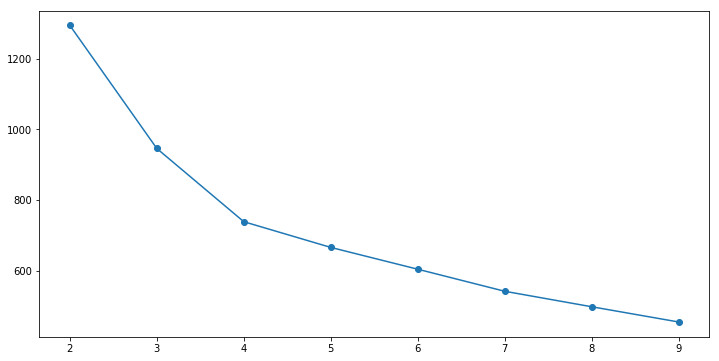

In [26]:
# Elbow plot to visually find out the optimal no of clusters

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [27]:
# The elbow plot confirms our visual analysis that there are likely 4  good clusters
# as in the above plot, the value significantly drops from 3 to 4. But there is no significat drop from 4 to 5.

final_model=KMeans(4,random_state=77)
final_model.fit(car_mpg_z)
prediction=final_model.predict(car_mpg_z)

#Append the prediction 
car_mpg_z["GROUP"] = prediction


In [28]:
#making copy of the data frame
car_mpg_z_copy = car_mpg_z.copy(deep = True)

In [29]:
car_mpg_z.head(5)

,cyl,disp,hp,wt,acc,yr,mpg,GROUP
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,-0.706439,1
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,-1.090751,1
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,-0.706439,1
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,-0.962647,1
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,-0.834543,1


In [30]:
centroids = final_model.cluster_centers_
centroids

array([[ 0.42558031,  0.30810076, -0.03401386,  0.34575408,  0.29922485,
         0.05143538, -0.49876792],
       [ 1.49819126,  1.50392292,  1.52168282,  1.40409797, -1.0861486 ,
        -0.68832385, -1.16379715],
       [-0.82534015, -0.78164519, -0.74051725, -0.76856959,  0.37498307,
         1.10179281,  1.18017325],
       [-0.85043429, -0.79990271, -0.55557971, -0.75486144,  0.32419661,
        -0.65531123,  0.19746294]])

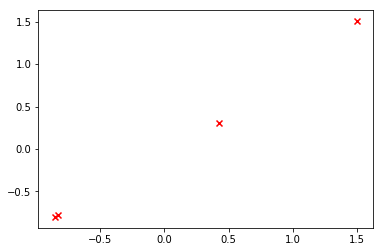

In [31]:
plt.scatter(centroids[:,0],centroids[:,1],marker="x",color='r')

In [32]:
#putting all the centroids in a 

centroid_df = pd.DataFrame(centroids, columns = list(X) )
centroid_df

,cyl,disp,hp,wt,acc,yr,mpg
0,0.425580,0.308101,-0.034014,0.345754,0.299225,0.051435,-0.498768
1,1.498191,1.503923,1.521683,1.404098,-1.086149,-0.688324,-1.163797
2,-0.825340,-0.781645,-0.740517,-0.768570,0.374983,1.101793,1.180173
3,-0.850434,-0.799903,-0.555580,-0.754861,0.324197,-0.655311,0.197463


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000022DEC22EDA0>,
      dtype=object)

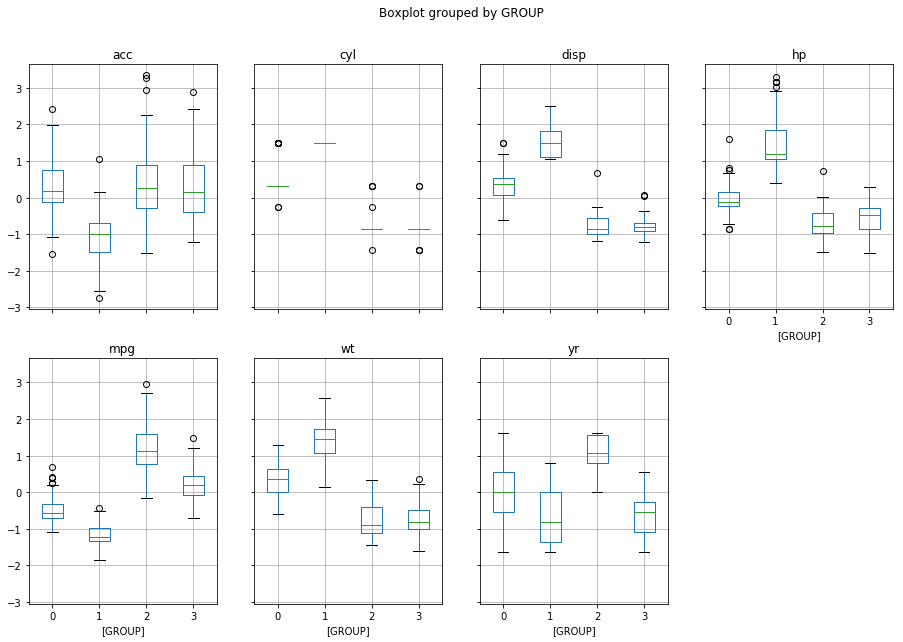

In [33]:
## Instead of interpreting the neumerical values of the centroids, let us do a visual analysis by converting the 
## centroids and the data in the cluster into box plots.
car_mpg_z.boxplot(by = 'GROUP',  layout=(2,4), figsize=(15, 10))

In [34]:
# There are many outliers on each dimension  (indicated by the black circles)
# Spread of data on each dimension (indicated by the whiskers is long ... due to the outliers)
# If the outliers are addressed,the clusters will overlap much less than right now 
# (except in year dimension which has no outlier)


In [35]:
# Addressing outliers at group level

data = car_mpg_z   # Renaming it to data. Remember data is not a copy of the dataframe
       
def replace(group):
    median, std = group.median(), group.std()  #Get the median and the standard deviation of every group 
    outliers = (group - median).abs() > 2*std # Subtract median from every member of each group. Take absolute values > 2std
    group[outliers] = group.median()       
    return group

data_corrected = (data.groupby('GROUP').transform(replace)) 
concat_data = data_corrected.join(pd.DataFrame(car_mpg_z['GROUP']))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000022DECAC4E48>,
      dtype=object)

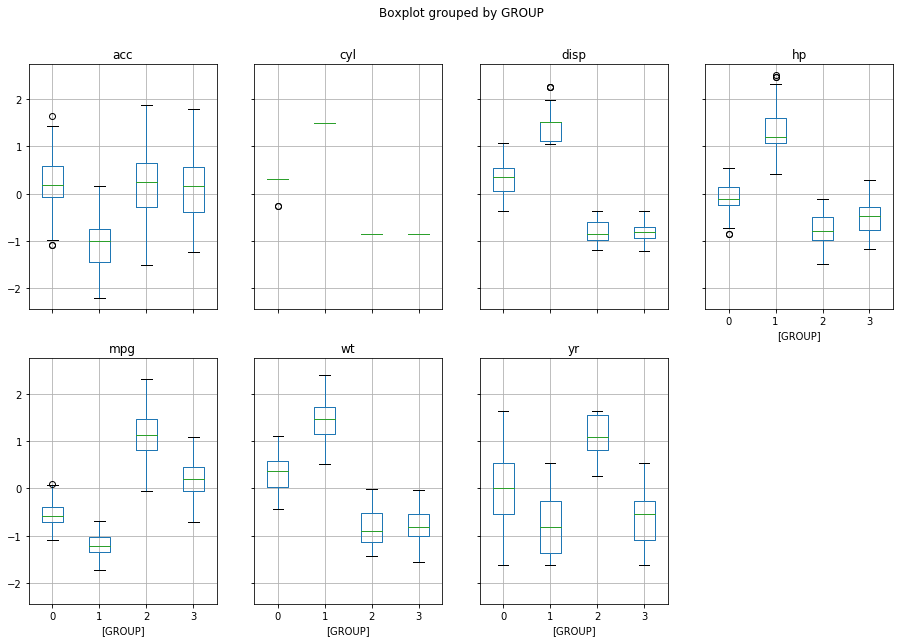

In [36]:
concat_data.boxplot(by = 'GROUP', layout=(2,4), figsize=(15, 10))

In [37]:
#Note:When we remove outliers and replace with median or mean, the distribution shape changes,
#the standard deviation becomes tighter creating new outliers.
#The new outliers would be much closer to the centre than original outliers so we accept them without modifying them

In [38]:
#Just doing the silhoutte analysis to find check the dendogram and clusters.

from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist  #Pairwise distribution between data points

In [39]:
# cophenet index is a measure of the correlation between the distance of points in feature space and distance on dendrogram
# closer it is to 1, the better is the clustering

Z = linkage(car_mpg_z, metric='euclidean',method='ward')
c, coph_dists = cophenet(Z , pdist(car_mpg_z))

print(c)

0.8014218369164865


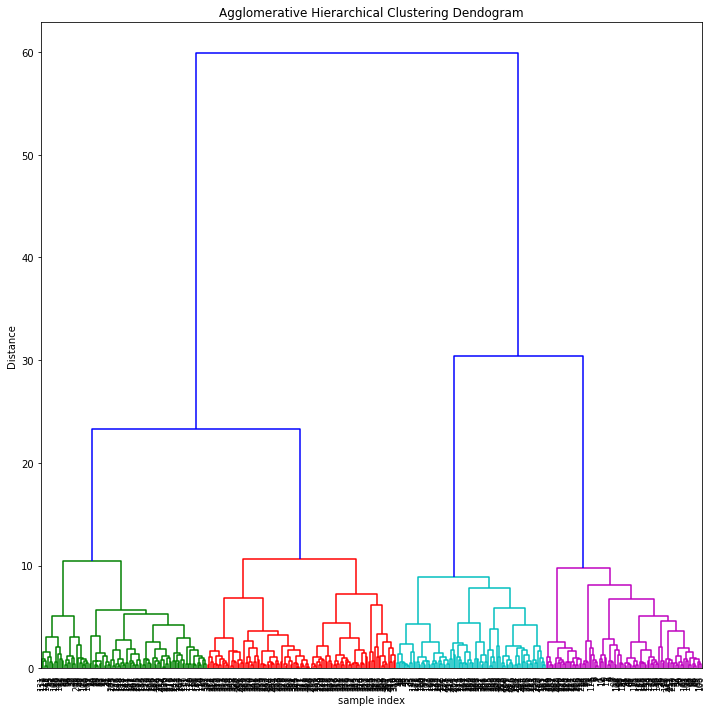

In [40]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold = 20,leaf_font_size=8. )
plt.tight_layout()

### 4.Use linear regression model on different clusters separately and print the coefficients of the models               individually (10 points)

In [41]:
car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null float64
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
car name    398 non-null object
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [42]:
car_mpg_copy = car_mpg.copy()

In [43]:
car_mpg_copy['GROUP'] = car_mpg_z['GROUP']

In [44]:
car_mpg_copy.head(5)

,cyl,disp,hp,wt,acc,yr,mpg,car name,GROUP
0,8,307.0,130.0,3504,12.0,70,18.0,chevrolet chevelle malibu,1
1,8,350.0,165.0,3693,11.5,70,15.0,buick skylark 320,1
2,8,318.0,150.0,3436,11.0,70,18.0,plymouth satellite,1
3,8,304.0,150.0,3433,12.0,70,16.0,amc rebel sst,1
4,8,302.0,140.0,3449,10.5,70,17.0,ford torino,1


In [45]:
car_mpg_copy.groupby('GROUP').count()
#tried to look into how many records each group has and with 4 cluseters we could see the data is evenly distrubuted.

,cyl,disp,hp,wt,acc,yr,mpg,car name
GROUP,,,,,,,,
0,90,90,90,90,90,90,90,90
1,94,94,94,94,94,94,94,94
2,114,114,114,114,114,114,114,114
3,100,100,100,100,100,100,100,100


In [46]:
#Below plot shows relationship of various attributes with mpg for all 4 groups.

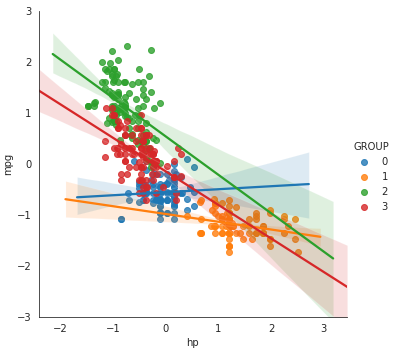

In [47]:
# mpg Vs hp

var = 'hp'

with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

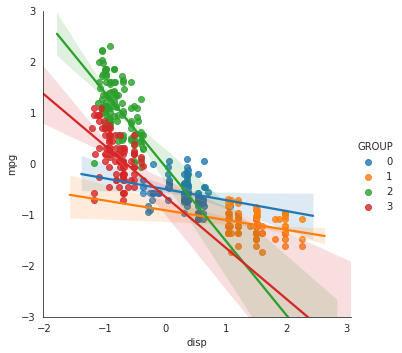

In [48]:
# mpg Vs disp

var = 'disp'

with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

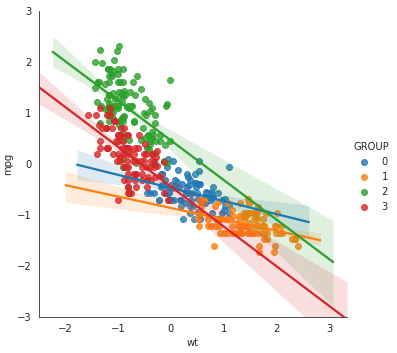

In [49]:
# mpg Vs hp

var = 'wt'

with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

In [50]:
#converted each group into a different dataframe(df1,df2,df3,df4)
#Then built a regression model on each of these dataframe
#Displayed the model intercept and coefficient.

In [51]:
df1 = car_mpg_copy.loc[car_mpg_copy['GROUP'] == 0]
df1.shape

(90, 9)

In [52]:
df2 = car_mpg_copy.loc[car_mpg_copy['GROUP'] == 1]
df2.shape

(94, 9)

In [53]:
df3 = car_mpg_copy.loc[car_mpg_copy['GROUP'] == 2]
df3.shape

(114, 9)

In [54]:
df4 = car_mpg_copy.loc[car_mpg_copy['GROUP'] == 3]
df4.shape

(100, 9)

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
x1 = df1.drop(['car name','GROUP','mpg'],axis=1)
y1 = df1['mpg']
model1 = LinearRegression()
model1.fit(x1,y1)
print('Model1 intercept:',model1.intercept_)
print('Model1 coef:',model1.coef_)

Model1 intercept: -5.368012259619242
Model1 coef: [ 0.81331502 -0.00108646 -0.03006537 -0.00357191 -0.18250718  0.49806931]


In [57]:
x2 = df2.drop(['car name','GROUP','mpg'],axis=1)
y2 = df2['mpg']
model2 = LinearRegression()
model2.fit(x2,y2)
print('Model2 intercept:',model2.intercept_)
print('Model2 coef:',model2.coef_)

Model2 intercept: 2.4451474263807036
Model2 coef: [ 0.         -0.00564162 -0.01902362 -0.00110037 -0.51930996  0.38323078]


In [58]:
x3 = df3.drop(['car name','GROUP','mpg'],axis=1)
y3 = df3['mpg']
model3 = LinearRegression()
model3.fit(x3,y3)
print('Model3 intercept:',model3.intercept_)
print('Model3 coef:',model3.coef_)

Model3 intercept: -24.04995389448598
Model3 coef: [ 4.90065744 -0.01238737 -0.06187237 -0.0084837   0.30977431  0.71868701]


In [59]:
x4 = df4.drop(['car name','GROUP','mpg'],axis=1)
y4 = df4['mpg']
model4 = LinearRegression()
model4.fit(x4,y4)
print('Model4 intercept:',model4.intercept_)
print('Model4 coef:',model4.coef_)

Model4 intercept: 13.091727986076506
Model4 coef: [ 2.99277204 -0.04829583 -0.04060314 -0.00510545 -0.21045528  0.32648268]
